In [ ]:

# 在CPU计算节点上运行
# taochen 2025-07-16

In [138]:
import cooler


In [139]:
cool_file_path = "/public/home/zju12218076/o_D/WT_HiC_1024.mcool"


In [141]:
clr = cooler.Cooler("/public/home/zju12218076/o_D/WT_HiC_1024.mcool::/resolutions/1024")
# balanced_clr = cooler.balance_cooler(clr, min_nnz=10, ignore_diags=2)

In [142]:
expected = cooltools.expected_cis(clr, view_df=None, nproc=8)

INFO:root:creating a Pool of 8 workers
/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [155]:
expected_per_dist = expected.groupby('dist_bp')['balanced.avg'].mean()
expected_per_dist.name = 'expected'

In [156]:
region = 'chr2:10,000,000-20,000,000'
pixels = clr.pixels(join=False).fetch(region)

In [158]:
bins = clr.bins()[:]

In [163]:
pixels = pixels.merge(
        bins[['chrom']],
        left_on='bin1_id',
        right_index=True
    ).rename(columns={'chrom': 'chrom1'}).merge(
        bins[['chrom']],
        left_on='bin2_id',
        right_index=True
    ).rename(columns={'chrom': 'chrom2'})

In [165]:
pixels = pixels[pixels['chrom1'] == pixels['chrom2']]

In [174]:
weights1 = bins['weight'].to_numpy()[pixels['bin1_id'].to_numpy()]
weights2 = bins['weight'].to_numpy()[pixels['bin2_id'].to_numpy()]
pixels['balanced'] = pixels['count'] * weights1 * weights2

/tmp/ipykernel_60972/1850411105.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pixels['balanced'] = pixels['count'] * weights1 * weights2


In [175]:
pixels['diag'] = pixels['bin2_id'] - pixels['bin1_id']

/tmp/ipykernel_60972/1682667059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pixels['diag'] = pixels['bin2_id'] - pixels['bin1_id']


In [176]:
oe_sparse = pd.merge(
        pixels,
        expected_per_diag,
        left_on='diag',
        right_index=True,
        how='left' # 使用 left join 以保留所有像素
    )

In [177]:
oe_sparse['o_over_e'] = oe_sparse['balanced'] / oe_sparse['expected']

KeyError: 'expected'

In [185]:
import cooltools.expect

ModuleNotFoundError: No module named 'cooltools.expect'

$$\frac{\text{obs} + \min(expe)}{exp + \min(expe)}$$

In [5]:
import cooltools
import numpy as np


# 我们通常对单个染色体进行操作
chrom_name = 'chr1'
raw_matrix = clr.matrix(balance=False).fetch(chrom_name)
balanced_matrix = clr.matrix(balance=True).fetch(chrom_name) # balance=True 会自动使用 'weight' 列

# 应用自适应粗粒化
# 'balanced_matrix' 作为参考，决定粗粒化的窗口大小
# 'raw_matrix' 是被粗粒化的对象，我们对原始读数进行求和
# np.sum 是汇集函数，将窗口内的读数相加
acg_matrix = cooltools.coarsegrain.adaptive_coarsegrain(
    raw_matrix,
    balanced_matrix,
    n_absent=3, # 控制平滑程度的参数
    function=np.sum
)

MemoryError: Unable to allocate 440. GiB for an array with shape (243122, 243122) and data type float64

In [ ]:
# 使用 cooltools 计算 P(s) 曲线 (Expected vs. Distance)
# 这里我们在平衡后的数据上进行计算，并聚合所有染色体的结果
# view_df 可以限定计算范围，这里我们排除小的scaffold
view_df = pd.DataFrame({
    'name': clr.chromnames,
    'start': 0,
    'end': clr.chromsizes.values
})

# 计算期望值，结果是一个包含每个距离(diag)对应平均值(value)的DataFrame
expected_df = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    balance=True # 使用平衡后的数据
)

# 构建特定染色体的背景矩阵
# cooltools.diagtoolz.block_diag_viewframe 可以帮助构建这个矩阵
# 这是一个更直接的方法：
from cooltools.lib.numutils import LazyToeplitz
n_bins = clr.matrix(balance=False).fetch(chrom_name).shape[0]

# expected_df['balanced.avg.value'] 包含了每个距离的期望值
# LazyToeplitz 可以高效地构建一个以这个向量为对角线值的托普利兹矩阵
background_matrix = LazyToeplitz(expected_df['balanced.avg.value'].values[:n_bins])
background_matrix = background_matrix.to_array() # 转换为numpy数组

In [ ]:
# 从背景矩阵中找到非零的最小值作为稳定项
# 直接用background_matrix.min()可能为0，所以要找非零最小值
min_val = background_matrix[background_matrix > 0].min()

# 应用最终的归一化公式
# 使用第2步得到的 acg_matrix
# 使用第3步得到的 background_matrix
# 注意：确保它们的维度一致
assert acg_matrix.shape == background_matrix.shape

genome_interaction_matrix = (acg_matrix + min_val) / (background_matrix + min_val)

# 这个 genome_interaction_matrix 就是最终的目标产物
# 在这个矩阵上，TADs会表现为对角线上的方形高信号区域
# 染色质环会表现为远离对角线的点状高信号

In [6]:
import os, subprocess
import pandas as pd
import bioframe
import cooltools
import cooler
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams['font.size']=12

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorials rely on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")


In [7]:
from IPython.display import Image

In [8]:
!cooltools -h

Usage: cooltools [OPTIONS] COMMAND [ARGS]...

  Type -h or --help after any subcommand for more information.

Options:
  -v, --verbose  Verbose logging
  -d, --debug    Post mortem debugging
  -V, --version  Show the version and exit.
  -h, --help     Show this message and exit.

Commands:
  coverage        Calculate the sums of cis and genome-wide contacts (aka...
  dots            Call dots on a Hi-C heatmap that are not larger than...
  eigs-cis        Perform eigen value decomposition on a cooler matrix to...
  eigs-trans      Perform eigen value decomposition on a cooler matrix to...
  expected-cis    Calculate expected Hi-C signal for cis regions of...
  expected-trans  Calculate expected Hi-C signal for trans regions of...
  genome          Utilities for binned genome assemblies.
  insulation      Calculate the diamond insulation scores and call...
  pileup          Perform retrieval of the snippets from .cool file.
  random-sample   Pick a random sample of contacts from a Hi-C 

In [17]:
!cooler show {cool_file_path}::/resolutions/1024 'chr2' -o "./chr2.png" --force

Traceback (most recent call last):
  File "/public/home/zju12218076/miniconda3/envs/project/bin/cooler", line 8, in <module>
    sys.exit(cli())
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 1442, in __call__
    return self.main(*args, **kwargs)
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 1363, in main
    rv = self.invoke(ctx)
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 1830, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 1226, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 794, in invoke
    return callback(*args, **kwargs)
  File "/public/home/zju12218

              total        used        free      shared  buff/cache   available
Mem:            503          99         388           3          14         398
Swap:             0           0           0


In [26]:
# hg38_chromsizes = bioframe.load_fasta('./data/hg38.fa')
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
view_hg38 = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

In [30]:
clr = cooler.Cooler(f'{cool_file_path}::/resolutions/1024')

In [33]:
view_hg38 = view_hg38[view_hg38.chrom.isin(clr.chromnames)].reset_index(drop=True)
view_hg38.to_csv("./develop_test/view_hg38.tsv", index=False, header=False, sep='\t')

In [34]:
!cooltools expected-cis {cool_file_path}::resolutions/1024 --nproc 12 -o './develop_test/test.expected.cis.1024.tsv' --view "./develop_test/view_hg38.tsv"


INFO:root:creating a Pool of 12 workers
/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [36]:
output = pd.read_table("./develop_test/test.expected.cis.1024.tsv")

In [37]:
output.head()

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
0,chr1_p,chr1_p,0,0,NaN,120508,107812,NaN,NaN,NaN,NaN
1,chr1_p,chr1_p,1,1024,NaN,120507,101770,NaN,NaN,NaN,NaN
2,chr1_p,chr1_p,2,2048,0.006015,120506,101424,185556.0,610.082997,1.539807,0.006015
3,chr1_p,chr1_p,3,3072,0.006015,120505,101357,183734.0,609.633004,1.524700,0.006015
4,chr1_p,chr1_p,4,4096,0.005744,120504,101353,174867.0,582.133823,1.451130,0.005744


In [41]:
!cooler dump --header -t bins {cool_file_path}::/resolutions/1024 | cut -f1-3 > ./develop_test/bins.1024.tsv


In [43]:
!cooltools genome gc ./develop_test/bins.1024.tsv data/hg38.fa > ./develop_test/gc.1024.tsv

In [45]:
!cooltools eigs-cis -o develop_test/test.eigs.1024 --view ./develop_test/view_hg38.tsv \
    --phasing-track ./develop_test/gc.1024.tsv --n-eigs 1 {cool_file_path}::resolutions/1024

/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/cli/eigs_cis.py:143: FutureWarning: The 'verbose' keyword in pd.read_table is deprecated and will be removed in a future version.
  track_df = pd.read_table(
Traceback (most recent call last):
  File "/public/home/zju12218076/miniconda3/envs/project/bin/cooltools", line 8, in <module>
    sys.exit(cli())
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 1442, in __call__
    return self.main(*args, **kwargs)
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 1363, in main
    rv = self.invoke(ctx)
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 1830, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/click/core.py", line 1226, 

In [46]:
!cooltools eigs-cis -h

Usage: cooltools eigs-cis [OPTIONS] COOL_PATH

  Perform eigen value decomposition on a cooler matrix to calculate
  compartment signal by finding the eigenvector that correlates best with the
  phasing track.

  COOL_PATH : the paths to a .cool file with a balanced Hi-C map. Use the '::'
  syntax to specify a group path in a multicooler file.

  TRACK_PATH : the path to a BedGraph-like file that stores phasing track as
  track-name named column.

  BedGraph-like format assumes tab-separated columns chrom, start, stop and
  track-name.

Options:
  --phasing-track TRACK_PATH  Phasing track for orienting and ranking
                              eigenvectors,provided as
                              /path/to/track::track_value_column_name.
  --view, --regions TEXT      Path to a BED file which defines which regions
                              of the chromosomes to use (only implemented for
                              cis contacts). Note that '--regions' is the
                       

Usage: cooler dump [OPTIONS] COOL_PATH
Try 'cooler dump -h' for help.

Error: Missing argument 'COOL_PATH'.


In [78]:
!cooler dump --range chr22 --join {cool_file_path}::/resolutions/1024 > ./develop_test/WT_chr22.txt

In [64]:
from pyfaidx import Fasta

In [65]:
fasta = Fasta("./data/hg38.fa")

In [75]:
with open("./develop_test/hg38_chorom_length.size", 'w') as file:
    for chromsome in fasta.keys():
        file.writelines(f'{chromsome}\t{len(fasta[chromsome])}\n')


In [79]:
!cooler load -f bg2 ./develop_test/hg38_chorom_length.size:1024 ./develop_test/WT_chr22.txt ./develop_test/WT_chr22.cool

INFO:cooler.cli.load:fields: {'chrom1': 0, 'start1': 1, 'end1': 2, 'chrom2': 3, 'start2': 4, 'end2': 5, 'count': 6}
INFO:cooler.cli.load:dtypes: {'chrom1': <class 'str'>, 'start1': <class 'int'>, 'end1': <class 'int'>, 'chrom2': <class 'str'>, 'start2': <class 'int'>, 'end2': <class 'int'>, 'count': <class 'numpy.int32'>}
INFO:cooler.cli.load:symmetric-upper: True
INFO:cooler.create:Writing chunk 0: /public/home/zju12218076/temp/develop_test/tmpkq3k_59p.multi.cool::0
INFO:cooler.create:Creating cooler at "/public/home/zju12218076/temp/develop_test/tmpkq3k_59p.multi.cool::/0"
INFO:cooler.create:Writing chroms
INFO:cooler.create:Writing bins
INFO:cooler.create:Writing pixels
INFO:cooler.create:Writing indexes
INFO:cooler.create:Writing info
INFO:cooler.create:Merging into ./develop_test/WT_chr22.cool
INFO:cooler.create:Creating cooler at "/public/home/zju12218076/temp/develop_test/WT_chr22.cool::/"
INFO:cooler.create:Writing chroms
INFO:cooler.create:Writing bins
INFO:cooler.create:Writi

In [112]:
!cooltools expected-cis ./develop_test/WT_chr22.cool --nproc 12 -o ./develop_test/test_chr22.expected.cis.1024.tsv

INFO:root:creating a Pool of 12 workers
/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [114]:
!cooltools --help

Usage: cooltools [OPTIONS] COMMAND [ARGS]...

  Type -h or --help after any subcommand for more information.

Options:
  -v, --verbose  Verbose logging
  -d, --debug    Post mortem debugging
  -V, --version  Show the version and exit.
  -h, --help     Show this message and exit.

Commands:
  coverage        Calculate the sums of cis and genome-wide contacts (aka...
  dots            Call dots on a Hi-C heatmap that are not larger than...
  eigs-cis        Perform eigen value decomposition on a cooler matrix to...
  eigs-trans      Perform eigen value decomposition on a cooler matrix to...
  expected-cis    Calculate expected Hi-C signal for cis regions of...
  expected-trans  Calculate expected Hi-C signal for trans regions of...
  genome          Utilities for binned genome assemblies.
  insulation      Calculate the diamond insulation scores and call...
  pileup          Perform retrieval of the snippets from .cool file.
  random-sample   Pick a random sample of contacts from a Hi-C 

In [92]:
!cooltools expected-cis --help

Usage: cooltools expected-cis [OPTIONS] COOL_PATH

  Calculate expected Hi-C signal for cis regions of chromosomal interaction
  map: average of interactions separated by the same genomic distance, i.e.
  are on the same diagonal on the cis-heatmap.

  When balancing weights are not applied to the data, there is no masking of
  bad bins performed.

  COOL_PATH : The paths to a .cool file with a balanced Hi-C map.

Options:
  -p, --nproc INTEGER      Number of processes to split the work
                           between.[default: 1, i.e. no process pool]
  -c, --chunksize INTEGER  Control the number of pixels handled by each worker
                           process at a time.  [default: 10000000]
  -o, --output TEXT        Specify output file name to store the expected in a
                           tsv format.
  --view, --regions PATH   Path to a 3 or 4-column BED file with genomic
                           regions to calculated cis-expected on. When region
                       

In [95]:
clr = cooler.Cooler("./develop_test/WT_chr22.cool")
cooler.balance_cooler(clr, min_nnz=10, ignore_diags=2)

/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(array([nan, nan, nan, ..., nan, nan, nan], shape=(3134296,)),
 {'tol': 1e-05,
  'min_nnz': 10,
  'min_count': 0,
  'mad_max': 5,
  'cis_only': False,
  'ignore_diags': 2,
  'scale': np.float64(222.7419718369134),
  'converged': np.True_,
  'var': np.float64(8.965792502266495e-06),
  'divisive_weights': False})

In [99]:
!cooler balance --help

Usage: cooler balance [OPTIONS] COOL_PATH

  Out-of-core matrix balancing.

  Matrix must be symmetric. See the help for various filtering options to mask
  out poorly mapped bins.

  COOL_PATH : Path to a COOL file.

Options:
  --cis-only                      Calculate weights against intra-chromosomal
                                  data only instead of genome-wide.
  --trans-only                    Calculate weights against inter-chromosomal
                                  data only instead of genome-wide.
  --ignore-diags INTEGER          Number of diagonals of the contact matrix to
                                  ignore, including the main diagonal.
                                  Examples: 0 ignores nothing, 1 ignores the
                                  main diagonal, 2 ignores diagonals (-1, 0,
                                  1), etc.  [default: 2]
  --ignore-dist INTEGER           Distance from the diagonal in bp to ignore.
                                  The maxi

In [111]:
!cooler balance ./develop_test/WT_chr22.cool --force

INFO:cooler.cli.balance:Balancing "./develop_test/WT_chr22.cool"
INFO:cooler._balance:variance is 6680.998949639141
INFO:cooler._balance:variance is 4340.688547312619
INFO:cooler._balance:variance is 514.3593710050717
INFO:cooler._balance:variance is 2305.191854619187
INFO:cooler._balance:variance is 341.53346562527287
INFO:cooler._balance:variance is 1458.3117153845596
INFO:cooler._balance:variance is 247.2274237340348
INFO:cooler._balance:variance is 951.7462211950673
INFO:cooler._balance:variance is 186.9478722339375
INFO:cooler._balance:variance is 630.1726517463761
INFO:cooler._balance:variance is 144.6372199000285
INFO:cooler._balance:variance is 422.2271948033763
INFO:cooler._balance:variance is 112.9859003730683
INFO:cooler._balance:variance is 286.07250815128725
INFO:cooler._balance:variance is 88.427342672697
INFO:cooler._balance:variance is 195.85892397018566
INFO:cooler._balance:variance is 69.04828358642034
INFO:cooler._balance:variance is 135.38267287621272
INFO:cooler._b

In [120]:
!ls -lh ./develop_test/






总用量 797M
-rw-r--r-- 1 zju12218076 zju0500033  69M 7月  17 02:22 bins.1024.tsv
-rw-r--r-- 1 zju12218076 zju0500033 102M 7月  17 02:25 gc.1024.tsv
-rw-r--r-- 1 zju12218076 zju0500033  12K 7月  17 03:20 hg38_chorom_length.size
-rw-r--r-- 1 zju12218076 zju0500033 168M 7月  17 05:09 test_chr22.expected.cis.1024.tsv
-rw-r--r-- 1 zju12218076 zju0500033 343M 7月  17 02:13 test.expected.cis.1024.tsv
-rw-r--r-- 1 zju12218076 zju0500033  60K 7月  14 10:26 test_region.bed
-rw-r--r-- 1 zju12218076 zju0500033 337K 7月  14 10:26 train_region.bed
-rw-r--r-- 1 zju12218076 zju0500033  59K 7月  14 10:26 validation_region.bed
-rw-r--r-- 1 zju12218076 zju0500033   57 7月  17 03:32 view_hg38_22.tsv
-rw-r--r-- 1 zju12218076 zju0500033 1.4K 7月  17 02:09 view_hg38.tsv
-rw-r--r-- 1 zju12218076 zju0500033 4.0M 7月  17 05:08 WT_chr22.cool
-rw-r--r-- 1 zju12218076 zju0500033  124 7月  17 05:51 WT_chr22.eigs.1024.cis.lam.txt
-rw-r--r-- 1 zju12218076 zju0500033 2.3M 7月  17 05:51 WT_chr22.eigs.1024.cis.vecs.tsv
-rw-r--r-- 1 zju

In [ ]:
# !cooltools saddle --qrange 0.02 0.98 --fig png -o outputs/test.saddle.cis.100000 
# --view data/view_hg38.tsv 
#     $cool_file::resolutions/100000 outputs/test.eigs.100000.cis.vecs.tsv outputs/test.expected.cis.100000.tsv


In [119]:
!cooltools eigs-cis -o develop_test/WT_chr22.eigs.1024 \
    --view develop_test/view_hg38_22.tsv \
    --phasing-track develop_test/gc.1024.tsv \
    --n-eigs 1 ./develop_test/WT_chr22.cool

/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/cli/eigs_cis.py:143: FutureWarning: The 'verbose' keyword in pd.read_table is deprecated and will be removed in a future version.
  track_df = pd.read_table(


In [137]:
!cooltools saddle --qrange 0.02 0.98 \
    --fig png -o develop_test/test_chr22.saddle.cis.1024 \
    --view develop_test/view_hg38_22.tsv \
    ./develop_test/WT_chr22.cool \
    ./develop_test/WT_chr22.eigs.1024.cis.vecs.tsv \
    ./develop_test/test_chr22.expected.cis.1024.tsv


/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/cli/saddle.py:224: FutureWarning: The 'verbose' keyword in pd.read_table is deprecated and will be removed in a future version.
  track = pd.read_table(
Traceback (most recent call last):
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/lib/io.py", line 327, in read_expected_from_file
    _ = is_valid_expected(
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/lib/checks.py", line 383, in is_valid_expected
    return _is_compatible_cis_expected(
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/lib/checks.py", line 254, in _is_compatible_cis_expected
    raise e
  File "/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/lib/checks.py", line 221, in _is_compatible_cis_expected
    _is_expected_cataloged(expected_df, verify_view

In [122]:
!cooltools saddle --help

Usage: cooltools saddle [OPTIONS] COOL_PATH TRACK_PATH EXPECTED_PATH

  Calculate saddle statistics and generate saddle plots for an arbitrary
  signal track on the genomic bins of a contact matrix.

  COOL_PATH : The paths to a .cool file with a balanced Hi-C map. Use the '::'
  syntax to specify a group path in a multicooler file.

  TRACK_PATH : The path to bedGraph-like file with a binned compartment track
  (eigenvector), including a header. Use the '::' syntax to specify a column
  name.

  EXPECTED_PATH : The paths to a tsv-like file with expected signal, including
  a header. Use the '::' syntax to specify a column name.

  Analysis will be performed for chromosomes referred to in TRACK_PATH, and
  therefore these chromosomes must be a subset of chromosomes referred to in
  COOL_PATH and EXPECTED_PATH.

  COOL_PATH, TRACK_PATH and EXPECTED_PATH must be binned at the same
  resolution (expect for  EXPECTED_PATH in case of trans contact type).

  EXPECTED_PATH must contain at lea

In [123]:
! head ./develop_test/test_chr22.expected.cis.1024.tsv

region1	region2	dist	dist_bp	contact_frequency	n_total	n_valid	count.sum	balanced.sum	count.avg	balanced.avg
chr1	chr1	0	0	nan	243122	0	nan	nan	nan	nan
chr1	chr1	1	1024	nan	243121	0	nan	nan	nan	nan
chr1	chr1	2	2048	nan	243120	0	0.0	0.0	0.0	nan
chr1	chr1	3	3072	nan	243119	0	0.0	0.0	0.0	nan
chr1	chr1	4	4096	nan	243118	0	0.0	0.0	0.0	nan
chr1	chr1	5	5120	nan	243117	0	0.0	0.0	0.0	nan
chr1	chr1	6	6144	nan	243116	0	0.0	0.0	0.0	nan
chr1	chr1	7	7168	nan	243115	0	0.0	0.0	0.0	nan
chr1	chr1	8	8192	nan	243114	0	0.0	0.0	0.0	nan


In [135]:
import pandas as pd

data = pd.read_table("develop_test/view_hg38_22.tsv")

In [136]:
# data[~np.isnan(data["weight"])]
data

,chr22,0,15000000,chr22_p
0,chr22,15000000,50818468,chr22_q


0        True
1        True
2        True
3        True
4        True
         ... 
49623    True
49624    True
49625    True
49626    True
49627    True
Name: weight, Length: 49628, dtype: bool

In [145]:
!cooltools

Usage: cooltools [OPTIONS] COMMAND [ARGS]...

  Type -h or --help after any subcommand for more information.

Options:
  -v, --verbose  Verbose logging
  -d, --debug    Post mortem debugging
  -V, --version  Show the version and exit.
  -h, --help     Show this message and exit.

Commands:
  coverage        Calculate the sums of cis and genome-wide contacts (aka...
  dots            Call dots on a Hi-C heatmap that are not larger than...
  eigs-cis        Perform eigen value decomposition on a cooler matrix to...
  eigs-trans      Perform eigen value decomposition on a cooler matrix to...
  expected-cis    Calculate expected Hi-C signal for cis regions of...
  expected-trans  Calculate expected Hi-C signal for trans regions of...
  genome          Utilities for binned genome assemblies.
  insulation      Calculate the diamond insulation scores and call...
  pileup          Perform retrieval of the snippets from .cool file.
  random-sample   Pick a random sample of contacts from a Hi-C 

In [146]:
!pwd

/public/home/zju12218076/temp


In [147]:
!cooltools expected-cis \
    -p 8 \
    -o ./develop_test/wt_expected_1024bp.tsv \
    ../o_D/WT_HiC_1024.mcool:://resolutions/1024

INFO:root:creating a Pool of 8 workers
/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [149]:
!ls -lh ./develop_test/wt_expected_1024bp.tsv

-rw-r--r-- 1 zju12218076 zju0500033 342M 7月  17 07:02 ./develop_test/wt_expected_1024bp.tsv


In [187]:
cooltools.__version__

'0.7.1'

In [191]:
# cool_file = cooltools.download_data("HFF_MicroC", cache=True, data_dir="./testing")


In [267]:
clr = cooler.Cooler("../o_D/WT_HiC_1024.mcool::/resolutions/2048")
cooler.balance_cooler(clr, min_nnz=10, ignore_diags=2)

(array([nan, nan, nan, ..., nan, nan, nan], shape=(1507955,)),
 {'tol': 1e-05,
  'min_nnz': 10,
  'min_count': 0,
  'mad_max': 5,
  'cis_only': False,
  'ignore_diags': 2,
  'scale': np.float64(571.2951403889751),
  'converged': np.True_,
  'var': np.float64(8.266311660704492e-06),
  'divisive_weights': False})

In [272]:
region = 'chr1'
print(f"\nLoaded cooler file. Resolution: {clr.binsize / 1000} kb.")


Loaded cooler file. Resolution: 2.048 kb.


In [273]:
view_df = pd.DataFrame({'chrom': [region],
                        'start': [0],
                        'end': [clr.chromsizes[region]],
                        'name': [region]})

In [274]:
expected_df = cooltools.expected_cis(clr=clr, view_df=view_df, nproc=-1)


INFO:root:fallback to serial implementation.


ValueError: cooler is not balanced, orbalancing weight weight is not available in the cooler.Pass clr_weight_name=None explicitly to calculate expected on raw counts

In [271]:
t = clr.matrix(balance=True).fetch("chr2:100000-1246880")

ValueError: No column 'bins/weight'found. Use ``cooler.balance_cooler`` to calculate balancing weights or set balance=False.

In [204]:
t.shape

(1121, 1121)

In [207]:
expected_df.head()

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
0,chr1,chr1,0,0,NaN,243122,199330,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1,chr1,1,1024,0.000063,243121,187498,NaN,NaN,NaN,NaN,0.000063,0.000063
2,chr1,chr1,2,2048,0.005914,243120,186853,331758.0,1115.697426,1.364585,0.005971,0.005914,0.005914
3,chr1,chr1,3,3072,0.005858,243119,186794,329335.0,1112.939659,1.354625,0.005958,0.005858,0.005858
4,chr1,chr1,4,4096,0.005554,243118,186743,314545.0,1066.579421,1.293796,0.005711,0.005554,0.005554


In [208]:
expected_series = expected_df.set_index('dist')['balanced.avg']

In [215]:
rows, cols = t.shape


In [221]:
dist_matrix_bins = np.abs(np.arange(rows)[:, None] - np.arange(cols)[None, :])

In [224]:
expected_2d_matrix = expected_series.reindex(dist_matrix_bins.flatten()).values.reshape(rows, cols)

In [246]:
with np.errstate(divide='ignore', invalid='ignore'):
    oe_matrix = t / expected_2d_matrix
    # 替换可能由除以零引起的 Inf 值，通常它们应该被视为无效数据点
    oe_matrix[np.isinf(oe_matrix)] = np.nan

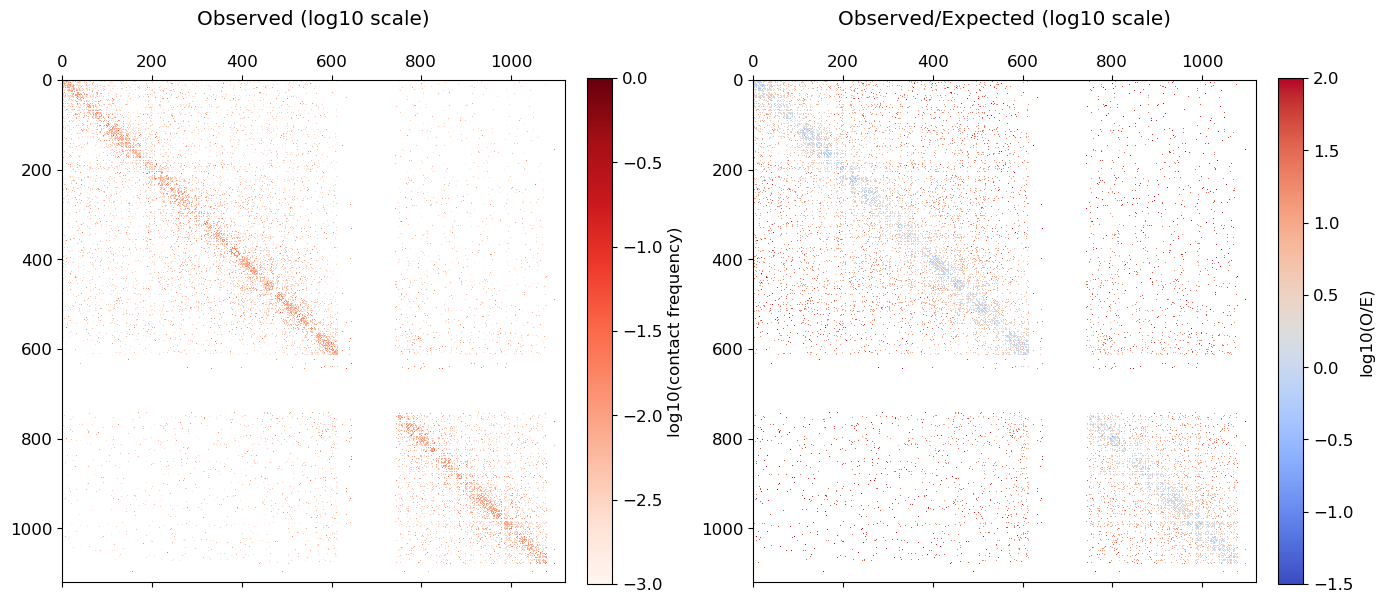

In [260]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- 绘制左图：原始观测矩阵 (Observed) ---
ax_obs = axes[0]
# 绘制 log10 变换后的观测矩阵。对数变换能更好地显示信号范围。
# 忽略 log10(0) 的警告
with np.errstate(divide='ignore'):
    im_obs = ax_obs.matshow(
        np.log10(t),
        cmap='Reds',
        vmin=-3, # 最小颜色值，可调整
        vmax=0   # 最大颜色值，可调整
    )
ax_obs.set_title(f'Observed (log10 scale)\n')
plt.colorbar(im_obs, ax=ax_obs, fraction=0.046, pad=0.04, label='log10(contact frequency)')



ax_oe = axes[1]
# O/E 矩阵通常使用发散色图 (diverging colormap)，以 1 为中心
# 在对数刻度下，O/E=1 对应 log10(1)=0。
# >1 是红色 (富集)，<1 是蓝色 (耗尽)
with np.errstate(divide='ignore'):
    im_oe = ax_oe.matshow(
        np.log10(oe_matrix),
        cmap='coolwarm',
        vmin=-1.5, # 负的最大绝对值，对应 log10(1/X)
        vmax=2   # 正的最大绝对值，对应 log10(X)
    )
ax_oe.set_title(f'Observed/Expected (log10 scale)\n')
plt.colorbar(im_oe, ax=ax_oe, fraction=0.046, pad=0.04, label='log10(O/E)')

plt.tight_layout()

In [259]:
np.nanmin(t), np.nanmax(t)

(np.float64(0.0), np.float64(0.18744973878126145))

In [261]:
clr.matrix?

Signature:
clr.matrix(
    field: 'str | None' = None,
    balance: 'bool | str' = True,
    sparse: 'bool' = False,
    as_pixels: 'bool' = False,
    join: 'bool' = False,
    ignore_index: 'bool' = True,
    divisive_weights: 'bool | None' = None,
    chunksize: 'int' = 10000000,
) -> 'RangeSelector2D'
Docstring:
Contact matrix selector

Parameters
----------
field : str, optional
    Which column of the pixel table to fill the matrix with. By
    default, the 'count' column is used.
balance : bool, optional
    Whether to apply pre-calculated matrix balancing weights to the
    selection. Default is True and uses a column named 'weight'.
    Alternatively, pass the name of the bin table column containing
    the desired balancing weights. Set to False to return untransformed
    counts.
sparse: bool, optional
    Return a scipy.sparse.coo_matrix instead of a dense 2D numpy array.
as_pixels: bool, optional
    Return a DataFrame of the corresponding rows from the pixel table
    ins